In [46]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [47]:
# Run SELECT and get results
pgw = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
pgw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147182 entries, 0 to 147181
Columns: 293 entries, player_name_id to saves_elo_adj_per90_running_avg_prev_10
dtypes: float64(288), object(5)
memory usage: 329.0+ MB


In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

def classify_players(df, position, features, cluster_labels, 
                     min_minutes=500, n_clusters=2, random_state=42):
    """
    Classify players within a position using PCA and K-Means clustering.
    
    Parameters:
    -----------
    df : DataFrame
        The full player gameweek dataframe
    position : str
        Position to filter (e.g., 'MID', 'DEF', 'FWD')
    features : list
        List of feature names to use for classification
        Example: ['goals_scored', 'assists', 'tackles', ...]
    cluster_labels : list
        Labels for clusters, ordered by attacking metric
        Example: ['Defensive', 'Offensive'] or ['Central', 'Attacking']
    min_minutes : int
        Minimum minutes played to include player
    n_clusters : int
        Number of clusters (default: 2)
    random_state : int
        Random state for reproducibility
        
    Returns:
    --------
    tuple : (updated_df, player_stats, pca, kmeans)
        - updated_df: Original df with new classification column
        - player_stats: Aggregated player statistics with clusters
        - pca: Fitted PCA object
        - kmeans: Fitted KMeans object
    """
    
    # Filter for specified position
    position_players = df[df['position'] == position].copy()
    
    if len(position_players) == 0:
        print(f"No players found for position: {position}")
        return df, None, None, None
    
    # Create aggregation dict: sum for all features
    agg_dict = {feat: 'sum' for feat in features if feat in position_players.columns}
    
    # Aggregate statistics per player
    player_stats = position_players.groupby('player_name_id').agg(agg_dict).dropna()
    
    # Filter by minimum playing time
    player_stats = player_stats[player_stats['minutes'] >= min_minutes]
    
    # Convert features to per 90 minutes (except 'minutes' itself)
    features_to_convert = [f for f in features if f != 'minutes' and f in player_stats.columns]
    for feature in features_to_convert:
        player_stats[f'{feature}_per90'] = (player_stats[feature] / player_stats['minutes']) * 90
    
    # Update feature list to use per90 versions
    per90_features = [f'{f}_per90' if f != 'minutes' else f for f in features if f in player_stats.columns or f'{f}_per90' in player_stats.columns]
    
    if len(player_stats) < n_clusters:
        print(f"Not enough players with {min_minutes}+ minutes: {len(player_stats)}")
        return df, None, None, None
    
    print(f"Number of {position} players analyzed: {len(player_stats)}")
    
    # Select only per90 features for clustering
    clustering_features = [f for f in per90_features if f in player_stats.columns]
    X = player_stats[clustering_features]
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA for dimension reduction
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    
    # Add results to dataframe
    player_stats['cluster'] = clusters
    player_stats['PC1'] = X_pca[:, 0]
    player_stats['PC2'] = X_pca[:, 1]
    
    # Determine cluster labels based on attacking metrics
    # Use first attacking feature in the config to determine order
    attacking_features = ['goals_scored_per90', 'assists_per90', 'expected_goals_per90', 'expected_goal_involvements_per90']
    sort_feature = None
    for feat in attacking_features:
        if feat in player_stats.columns:
            sort_feature = feat
            break
    
    if sort_feature:
        cluster_profiles = player_stats.groupby('cluster')[[sort_feature]].mean()
        print(f"\nCluster Profiles (sorted by {sort_feature}):")
        cluster_order = cluster_profiles[sort_feature].sort_values(ascending=False).index.tolist()
    else:
        cluster_order = list(range(n_clusters))
    
    # Map clusters to labels
    cluster_mapping = {cluster_order[i]: cluster_labels[i] for i in range(n_clusters)}
    player_stats['player_type'] = player_stats['cluster'].map(cluster_mapping)
    
    # Create interactive visualization with Plotly
    plot_df = player_stats.reset_index()
    
    # Create hover text with key stats (use per90 versions)
    hover_cols = []
    potential_hover = ['goals_scored_per90', 'assists_per90', 'tackles_per90', 'clean_sheets']
    for col in potential_hover:
        if col in plot_df.columns:
            hover_cols.append(col)
    hover_cols.append('minutes')  # Always include total minutes
    
    # Create custom hover data dict
    hover_data_dict = {
        'PC1': ':.2f',
        'PC2': ':.2f',
        'player_type': True,
    }
    for col in hover_cols:
        if col in plot_df.columns:
            hover_data_dict[col] = ':.2f'
    
    # Interactive scatter plot
    fig = px.scatter(
        plot_df,
        x='PC1',
        y='PC2',
        color='player_type',
        hover_name='player_name_id',
        hover_data=hover_data_dict,
        title=f'{position} Classification (PCA + K-Means) - Per 90 Metrics',
        labels={
            'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
            'player_type': 'Type'
        },
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(
        height=600,
        hovermode='closest',
        plot_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='lightgray'),
        yaxis=dict(showgrid=True, gridcolor='lightgray')
    )
    
    fig.show()
    
    # Also create static plot for feature importance
    components_df = pd.DataFrame(
        pca.components_.T,
        columns=['PC1', 'PC2'],
        index=clustering_features
    )
    components_df['abs_PC1'] = np.abs(components_df['PC1'])
    components_df = components_df.sort_values('abs_PC1', ascending=True)
    
    fig2, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(components_df)), components_df['PC1'])
    ax.set_yticks(range(len(components_df)))
    ax.set_yticklabels(components_df.index)
    ax.set_xlabel('PC1 Loading')
    ax.set_title('Feature Contributions to PC1 (Per 90 Metrics)')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Print classification summary
    print("\n" + "="*60)
    print(f"{position} CLASSIFICATION SUMMARY")
    print("="*60)
    for label in cluster_labels:
        count = (player_stats['player_type'] == label).sum()
        print(f"\n{label}: {count}")
    
    # Show top players in each category
    for i, label in enumerate(cluster_labels):
        print(f"\nTop 10 {label} (by {sort_feature if sort_feature else 'minutes'}):")
        category_players = player_stats[player_stats['player_type'] == label]
        
        # Display per90 stats
        display_cols = ['goals_scored_per90', 'assists_per90', 'minutes']
        if 'tackles_per90' in player_stats.columns:
            display_cols.insert(2, 'tackles_per90')
        if 'clean_sheets' in player_stats.columns:
            display_cols.insert(3, 'clean_sheets')
        
        available_cols = [col for col in display_cols if col in player_stats.columns]
        sort_col = sort_feature if sort_feature else 'minutes'
        print(category_players.nlargest(10, sort_col)[available_cols])
    
    # Merge classification back to original dataframe
    player_classification = player_stats[['player_type']].reset_index()
    df = df.merge(player_classification, on='player_name_id', how='left', suffixes=('', '_new'))
    
    # Handle column naming
    if 'player_type_new' in df.columns:
        df['player_type'] = df['player_type_new'].fillna(df.get('player_type', ''))
        df = df.drop(columns=['player_type_new'])
    
    print(f"\n✓ Classification complete! New column 'player_type' added to dataframe")
    
    return df, player_stats, pca, kmeans


In [49]:
pgw.columns.to_list()

['player_name_id',
 'element',
 'season',
 'value',
 'event',
 'minutes',
 'total_points',
 'team_elo',
 'opp_team_elo',
 'position',
 'goals_scored',
 'bonus',
 'bps',
 'clean_sheets',
 'goals_conceded',
 'was_home',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'team_name',
 'opp_team_name',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles',
 'saves',
 'player_season_minutes_total',
 'player_season_points_per90',
 'points_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'expected_goals_conceded_per90',
 'saves_per90',
 'bps_per90',
 'bonus_per90',
 'cbi_per90',
 'defensive_contribution_per90',
 'recoveries_per90',
 'tackles_per90',
 'elo_diff',
 'minutes_alltime_avg',
 'minutes_per90_alltime_avg',
 'minutes_running_avg_prev_3',
 'minutes_per90_running_avg_prev_3',
 'minutes_elo_adj_running_avg_prev_3',
 'minutes_elo_adj_per90_running_avg_prev_3',
 'minutes_running_avg_prev_5',
 'minutes_per90_running_avg_pre

Number of MID players analyzed: 477

Explained variance ratio: [0.27797136 0.21863041]
Total variance explained: 49.66%

Cluster Profiles (sorted by goals_scored_per90):


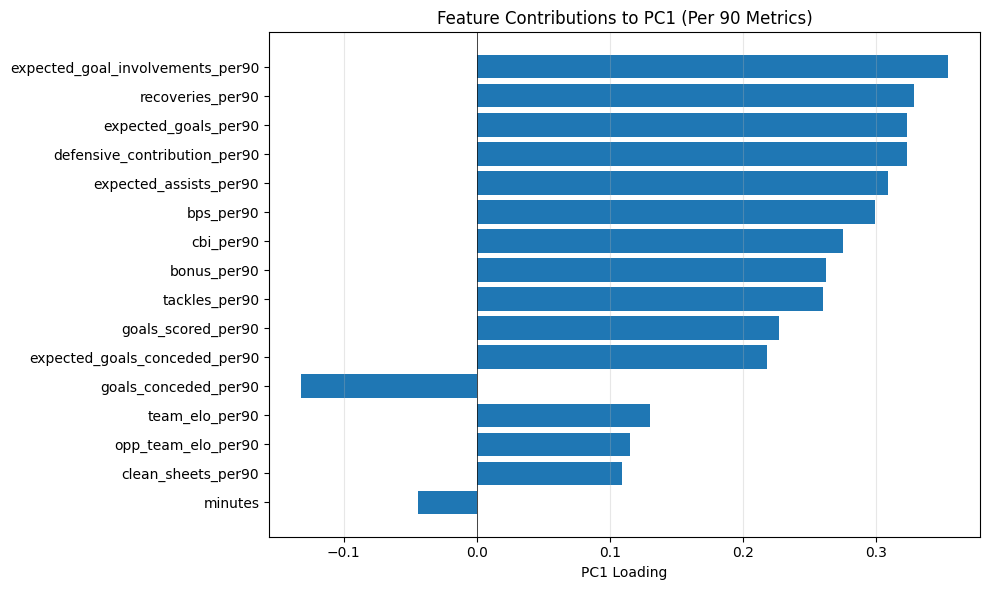


MID CLASSIFICATION SUMMARY

Offensive: 143

Defensive: 334

Top 10 Offensive (by goals_scored_per90):
                         goals_scored_per90  tackles_per90  clean_sheets  \
player_name_id                                                             
Gareth Bale                        1.178010       0.000000           4.0   
Donyell Malen                      0.832232       0.475561           1.0   
Richarlison de Andrade             0.697674       0.000000           7.0   
Emiliano Buendía Stati             0.666667       3.000000           2.0   
Diogo Teixeira da Silva            0.638298       0.000000          12.0   
Mohamed Salah                      0.633019       0.011723          64.0   
Cole Palmer                        0.528571       0.714286          19.0   
Luis DÃÂ­az                       0.509360       0.000000          15.0   
Phil Foden                         0.490878       0.330073          47.0   
Manor Solomon                      0.487805       0.000000   

In [50]:

# =============================================================================
# EXAMPLE 1: Classify Midfielders (Defensive vs Offensive)
# =============================================================================

features = ['minutes',
 'team_elo',
 'opp_team_elo',
 'goals_scored',
 'bonus',
 'bps',
 'clean_sheets',
 'goals_conceded',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles'
]

pgw, mid_stats, mid_pca, mid_kmeans = classify_players(
    df=pgw,
    position='MID',
    features=features,
    cluster_labels=['Offensive', 'Defensive'],  # Order: most attacking first
    min_minutes=500
)

Number of DEF players analyzed: 390

Explained variance ratio: [0.29086401 0.22114814]
Total variance explained: 51.20%

Cluster Profiles (sorted by goals_scored_per90):


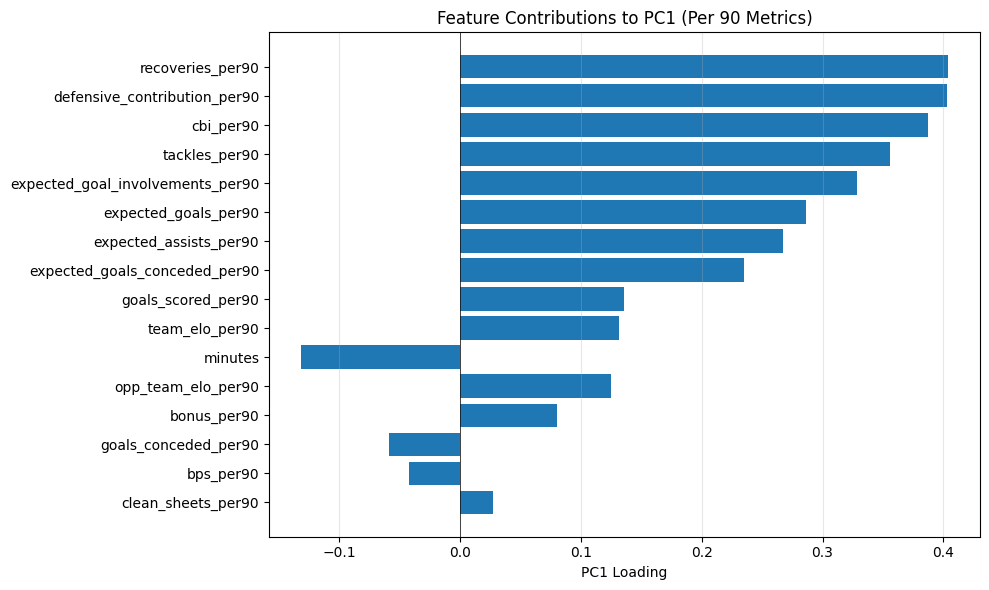


DEF CLASSIFICATION SUMMARY

Attacking: 48

Central: 342

Top 10 Attacking (by goals_scored_per90):
                                  goals_scored_per90  tackles_per90  \
player_name_id                                                        
Maxim De Cuyper                             0.257143       4.242857   
Nicolò Savona                               0.241935       7.620968   
Daniel Muñoz Mejía                          0.214286       2.214286   
Daniel Ballard                              0.191693       5.750799   
Joško Gvardiol                              0.189873       1.044304   
Malick Thiaw                                0.181452       3.266129   
Josh Acheampong                             0.174419       0.348837   
Jurriën Timber                              0.150376       8.195489   
Marc Guéhi                                  0.142857       5.142857   
Rúben dos Santos Gato Alves Dias            0.142292       0.498024   

                                  clean_sheets 

In [51]:

# =============================================================================
# EXAMPLE 2: Classify Defenders (Attacking vs Central)
# =============================================================================
pgw, def_stats, def_pca, def_kmeans = classify_players(
    df=pgw,
    position='DEF',
    features=features,
    cluster_labels=['Attacking', 'Central'],  # Order: most attacking first
    min_minutes=500
)